# Creating Bivariate Scatterplots

In [3]:
import geopandas as gpd
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt 

In [4]:
# setting wd 
import os
os.chdir('/users/bkung/fooddesertproject')

In [11]:
# loading in data 
def read_county_data(county_name):
    gdf = gpd.read_file(f"modeling_data/{county_name}_modeling_final.gpkg")
    return gdf 

harris_data = read_county_data("harris")
bexar_data = read_county_data("bexar")
travis_data = read_county_data("travis")
dallas_data = read_county_data("dallas")
tarrant_data = read_county_data("tarrant")

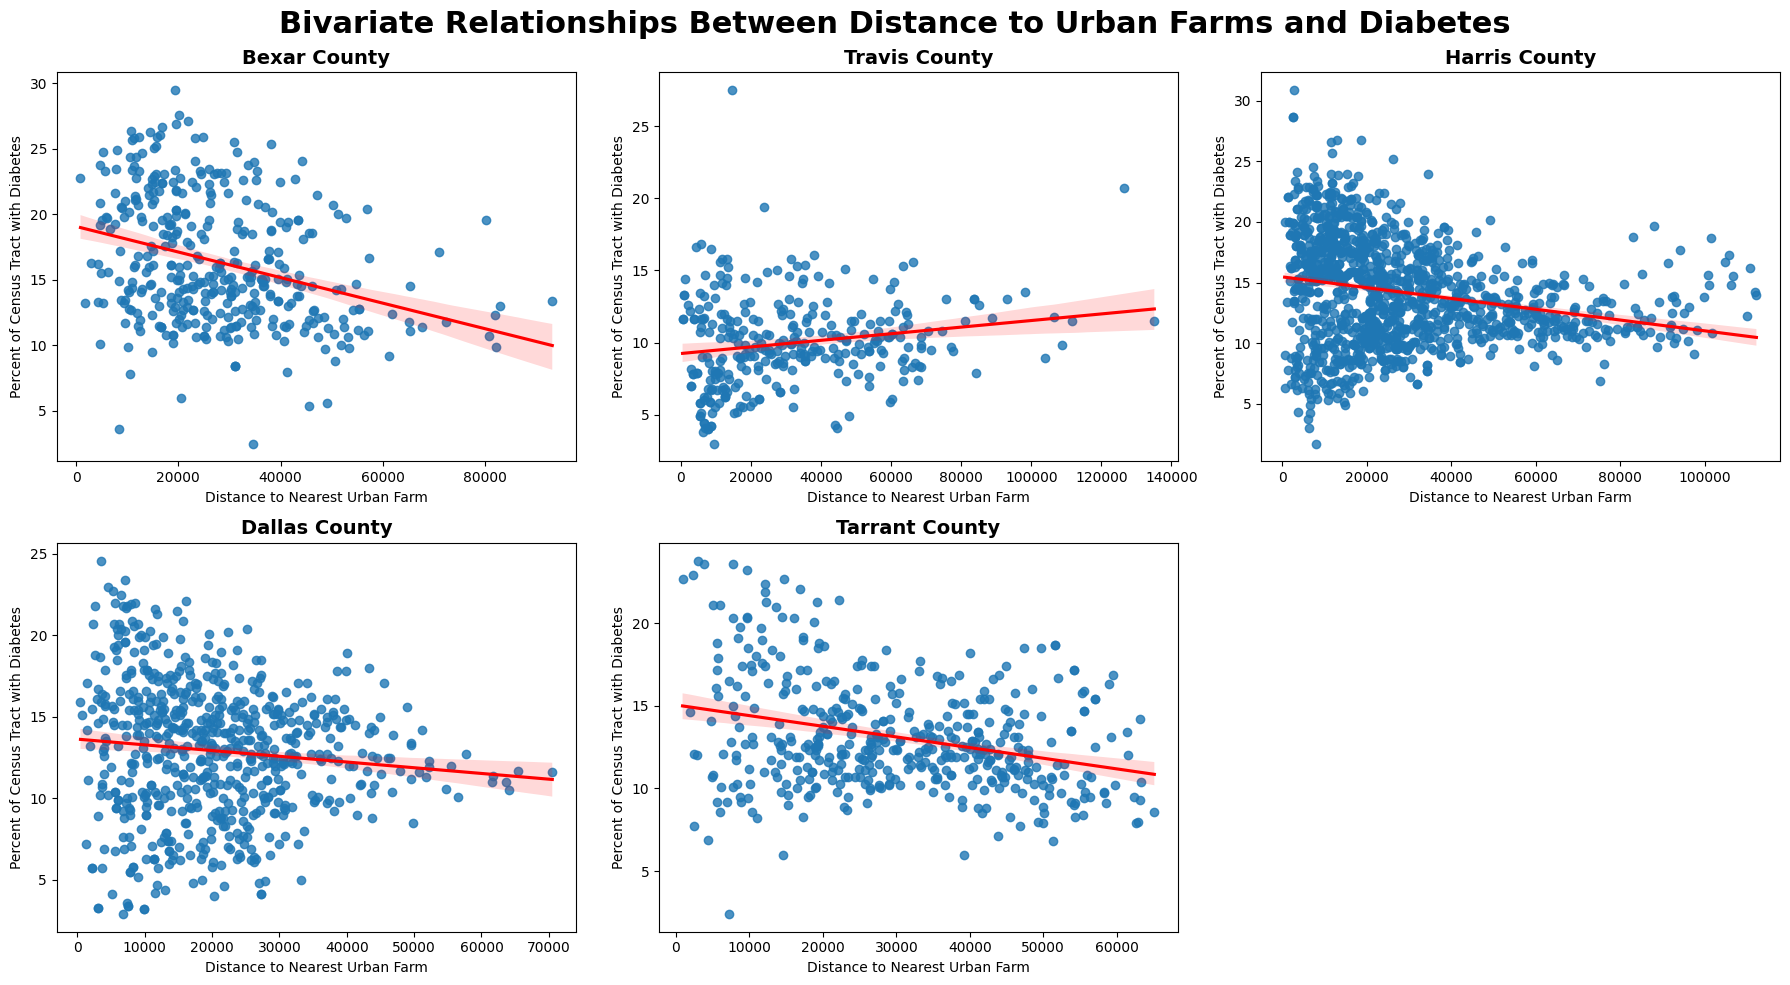

In [13]:
# GENERATING BIVARIATE SCATTERPLOTS 
# defining title names for each county
title_names = [
    "Bexar County",
    "Travis County",
    "Harris County",
    "Dallas County",
    "Tarrant County",
]

# defining datasets to pull from
dfs = [bexar_gdf, travis_gdf, harris_gdf, 
       dallas_gdf, tarrant_gdf]

# setting up grid layout
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()  # Flatten to easily index ax1 through ax6

# looping and plotting scatterplot on each respective axis 
for i, df in enumerate(dfs):
    current_ax = axes[i]

    # Draw the histogram with an optional smooth KDE density curve
    sns.regplot(
        data=df,
        x="distance_to_nearest_uf", 
        y= "E_DIABETES",
        ci=95,
        line_kws={"color": "red"},
        ax=current_ax
    )


    # titles
    current_ax.set_title(title_names[i], fontsize=14, fontweight="bold")
    current_ax.set_xlabel("Distance to Nearest Urban Farm")
    current_ax.set_ylabel("Percent of Census Tract with Diabetes")

# deleting empty 6th slot 
fig.delaxes(axes[5])

# overarching title
fig.suptitle(
    "Bivariate Relationships Between Distance to Urban Farms and Diabetes",  # Your main title text
    fontsize=22,  
    fontweight="bold",  
    y=0.98,  
)

# fixing layout and saving 
fig.tight_layout()
plt.savefig("Stat_Modeling/scatter_plots/bivariate_scatterplots.png", dpi=300, bbox_inches="tight")
plt.show()
